<a href="https://colab.research.google.com/github/saeedbhai0632-web/CS229_CourseWork/blob/main/CelebA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np
import os
from tqdm import tqdm  # progress bars for long training

torch.manual_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
if device.type != "cuda":
    print("WARNING: This week needs a GPU! Go to Runtime > Change runtime type > T4 GPU")

Using device: cuda


In [2]:
# CelebA: 200K celebrity faces, aligned and cropped
# We resize to 64x64 to keep training manageable on Colab T4

image_size = 64  # [PLAY] try 128 if you have memory

transform = transforms.Compose([
    transforms.Resize((image_size, image_size)),
    transforms.CenterCrop(image_size),   # CelebA images are 178x218
    transforms.ToTensor(),               # scales to [0, 1]
])

# Download CelebA (first time: ~1.5 GB download, ~5 min)
# Colab tip: mount Google Drive and store data there to avoid re-downloading
dataset = datasets.CelebA(
    root="./data", split="train", download=True, transform=transform
)

# CelebA has 162,770 training images. For faster iteration, use a subset:
# dataset = Subset(dataset, range(50000))  # [PLAY] use 50K for quick tests

batch_size = 64  # [PLAY] reduce to 32 if Colab runs OOM
train_loader = DataLoader(
    dataset, batch_size=batch_size, shuffle=True,
    num_workers=2, pin_memory=True  # speeds up GPU training
)

# Validation: use a small held-out set
# CelebA doesn't have a standard val split, so take last 10K
val_size = 10000
val_dataset = Subset(dataset, range(len(dataset) - val_size, len(dataset)))
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False,
                        num_workers=2, pin_memory=True)

# Sanity check
images, _ = next(iter(train_loader))
print(f"Batch shape: {images.shape}")  # [64, 3, 64, 64]
print(f"Pixel range: [{images.min():.2f}, {images.max():.2f}]")
print(f"Training samples: {len(dataset):,}")

Downloading...
From (original): https://drive.google.com/uc?id=0B7EVK8r0v71pZjFTYXZWM3FlRnM
From (redirected): https://drive.usercontent.google.com/download?id=0B7EVK8r0v71pZjFTYXZWM3FlRnM&confirm=t&uuid=b824717a-4fcd-48e7-9f2c-6b6878cb3f1f
To: /content/data/celeba/img_align_celeba.zip
100%|██████████| 1.44G/1.44G [00:14<00:00, 97.9MB/s]
Downloading...
From: https://drive.google.com/uc?id=0B7EVK8r0v71pblRyaVFSWGxPY0U
To: /content/data/celeba/list_attr_celeba.txt
100%|██████████| 26.7M/26.7M [00:00<00:00, 141MB/s] 
Downloading...
From: https://drive.google.com/uc?id=1_ee_0u7vcNLOfNLegJRHmolfH5ICW-XS
To: /content/data/celeba/identity_CelebA.txt
100%|██████████| 3.42M/3.42M [00:00<00:00, 61.7MB/s]
Downloading...
From: https://drive.google.com/uc?id=0B7EVK8r0v71pbThiMVRxWXZ4dU0
To: /content/data/celeba/list_bbox_celeba.txt
100%|██████████| 6.08M/6.08M [00:00<00:00, 224MB/s]
Downloading...
From: https://drive.google.com/uc?id=0B7EVK8r0v71pd0FJY3Blby1HUTQ
To: /content/data/celeba/list_landma

Batch shape: torch.Size([64, 3, 64, 64])
Pixel range: [0.00, 1.00]
Training samples: 162,770


In [3]:
class FaceVAE(nn.Module):
    def __init__(self, latent_dim=128, hidden_dims=None, kernel_size=3):
        """
        Args:
            latent_dim: size of the face code z        # [PLAY]
            hidden_dims: channel sizes per layer       # [PLAY] try [32,64,128,256]
            kernel_size: conv filter size              # [PLAY] try 5
        """
        super().__init__()
        self.latent_dim = latent_dim
        if hidden_dims is None:
            hidden_dims = [64, 128, 256, 512]  # [PLAY] ← change these four numbers!

        # ---- Encoder: 3×64×64 → latent distribution ----
        encoder_layers = []
        in_ch = 3  # RGB
        for out_ch in hidden_dims:
            encoder_layers.extend([
                nn.Conv2d(in_ch, out_ch, kernel_size=kernel_size, stride=2, padding=1),
                nn.BatchNorm2d(out_ch),  # helps with training stability at scale
                nn.ReLU(),
            ])
            in_ch = out_ch
        encoder_layers.append(nn.Flatten())
        self.encoder = nn.Sequential(*encoder_layers)

        # Flattened size: hidden_dims[-1] * (64 / 2^4)^2 = 512 * 4 * 4 = 8192
        n_layers = len(hidden_dims)
        spatial_size = 64 // (2 ** n_layers)  # 64/16 = 4
        self.flattened_size = hidden_dims[-1] * (spatial_size ** 2)

        self.fc_mu    = nn.Linear(self.flattened_size, latent_dim)
        self.fc_logvar = nn.Linear(self.flattened_size, latent_dim)

        # ---- Decoder: latent → 3×64×64 ----
        self.decoder_input = nn.Linear(latent_dim, self.flattened_size)

        decoder_layers = []
        rev_dims = list(reversed(hidden_dims))
        for i in range(len(rev_dims) - 1):
            decoder_layers.extend([
                nn.ConvTranspose2d(rev_dims[i], rev_dims[i+1],
                                   kernel_size=4, stride=2, padding=1),
                nn.BatchNorm2d(rev_dims[i+1]),
                nn.ReLU(),
            ])
        # Final layer: rev_dims[-1] → 3 (RGB)
        decoder_layers.extend([
            nn.ConvTranspose2d(rev_dims[-1], 3, kernel_size=4, stride=2, padding=1),
            nn.Sigmoid(),  # output in [0, 1]
        ])
        self.decoder = nn.Sequential(*decoder_layers)

        self.last_channel = hidden_dims[-1]
        self.spatial_size = spatial_size

    def encode(self, x):
        h = self.encoder(x)           # [B, flattened_size]
        mu = self.fc_mu(h)            # [B, latent_dim]
        logvar = self.fc_logvar(h)    # [B, latent_dim]
        return mu, logvar

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        h = self.decoder_input(z)                    # [B, flattened_size]
        h = h.view(-1, self.last_channel,
                   self.spatial_size, self.spatial_size)
        return self.decoder(h)                       # [B, 3, 64, 64]

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        recon = self.decode(z)
        return recon, mu, logvar

In [4]:
def vae_loss(recon, x, mu, logvar, beta=1.0):
    # For faces, we use MSE instead of BCE — works better for RGB
    # [PLAY] swap F.mse_loss for F.binary_cross_entropy and compare
    recon_loss = F.mse_loss(recon, x, reduction='sum')

    # KL Divergence: same closed form
    kl_loss = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())

    total = recon_loss + beta * kl_loss
    return total, recon_loss, kl_loss

In [5]:
def train_epoch(model, loader, optimizer, beta=1.0):
    model.train()
    total_loss, total_recon, total_kl = 0, 0, 0

    pbar = tqdm(loader, desc="Training", leave=False)
    for x, _ in pbar:
        x = x.to(device)

        optimizer.zero_grad()
        recon, mu, logvar = model(x)
        loss, recon_l, kl_l = vae_loss(recon, x, mu, logvar, beta=beta)
        loss.backward()
        optimizer.step()

        total_loss  += loss.item()
        total_recon += recon_l.item()
        total_kl    += kl_l.item()

        pbar.set_postfix({'loss': f'{loss.item()/len(x):.1f}'})

    n = len(loader.dataset)
    return total_loss / n, total_recon / n, total_kl / n


@torch.no_grad()
def evaluate(model, loader, beta=1.0):
    model.eval()
    total_loss, total_recon, total_kl = 0, 0, 0

    for x, _ in tqdm(loader, desc="Evaluating", leave=False):
        x = x.to(device)
        recon, mu, logvar = model(x)
        loss, recon_l, kl_l = vae_loss(recon, x, mu, logvar, beta=beta)
        total_loss  += loss.item()
        total_recon += recon_l.item()
        total_kl    += kl_l.item()

    n = len(loader.dataset)
    return total_loss / n, total_recon / n, total_kl / n

In [6]:
# ===== CONFIGURATION -- change these! =====
LATENT_DIM    = 128     # [PLAY] face code size
LEARNING_RATE = 1e-3    # [PLAY] try 5e-4
EPOCHS        = 30      # [PLAY] try 10 for quick, 50 for quality
BETA          = 0.5     # [PLAY] lower = sharper faces
# ==========================================

model = FaceVAE(latent_dim=LATENT_DIM).to(device)
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

# Print model size
n_params = sum(p.numel() for p in model.parameters())
print(f"Model parameters: {n_params:,}")

history = {"train_loss": [], "train_recon": [], "train_kl": [],
           "val_loss":  [], "val_recon":  [], "val_kl":  []}

print(f"{'Epoch':>6} {'Train Loss':>12} {'Train Recon':>12} {'Train KL':>12} "
      f"{'Val Loss':>12} {'Val Recon':>12} {'Val KL':>12}")
print("-" * 78)

for epoch in range(1, EPOCHS + 1):
    train_l, train_r, train_k = train_epoch(model, train_loader, optimizer, beta=BETA)
    val_l,   val_r,   val_k   = evaluate(model, val_loader, beta=BETA)

    for d, v in [("train_loss", train_l), ("train_recon", train_r), ("train_kl", train_k),
                 ("val_loss", val_l), ("val_recon", val_r), ("val_kl", val_k)]:
        history[d].append(v)

    print(f"{epoch:>6} {train_l:>12.2f} {train_r:>12.2f} {train_k:>12.2f} "
          f"{val_l:>12.2f} {val_r:>12.2f} {val_k:>12.2f}")

print("\nTraining complete! Save your model:")
torch.save(model.state_dict(), "face_vae_epoch{EPOCHS}.pt")

Model parameters: 7,464,003
 Epoch   Train Loss  Train Recon     Train KL     Val Loss    Val Recon       Val KL
------------------------------------------------------------------------------


     1       213.36       163.65        99.43       166.77       115.97       101.60


     2       162.48       113.53        97.90       156.10       107.05        98.09


     3       154.98       104.89       100.17       151.73       102.76        97.92


     4       150.99       100.45       101.09       147.75        98.25        98.99


...

    26       136.32        84.63       103.38       134.64        83.11       103.07


    27       136.20        84.52       103.35       134.78        84.05       101.45


    28       136.01        84.36       103.29       134.68        83.56       102.25


    29       135.88        84.24       103.28       134.63        83.47       102.32


    30       135.73        84.08       103.30       134.23        82.83       102.80

Training complete! Save your model:


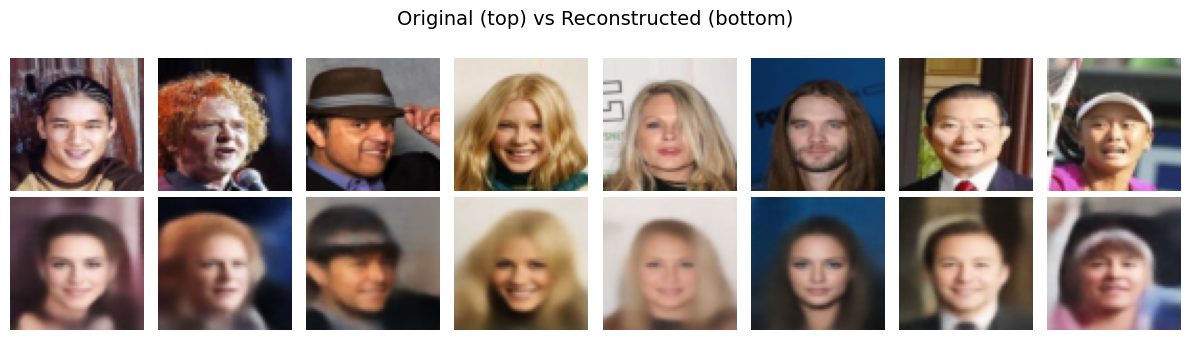

In [7]:
@torch.no_grad()
def show_face_reconstructions(model, loader, n=8):
    model.eval()
    x, _ = next(iter(loader))
    x = x[:n].to(device)

    recon, _, _ = model(x)

    fig, axes = plt.subplots(2, n, figsize=(n*1.5, 3.5))
    for i in range(n):
        # Denormalize: channels to last dim for imshow
        axes[0, i].imshow(x[i].permute(1, 2, 0).cpu())
        axes[0, i].axis('off')
        axes[1, i].imshow(recon[i].permute(1, 2, 0).cpu())
        axes[1, i].axis('off')

    axes[0, 0].set_ylabel("Original", fontsize=12)
    axes[1, 0].set_ylabel("Reconstructed", fontsize=12)
    plt.suptitle("Original (top) vs Reconstructed (bottom)", fontsize=14)
    plt.tight_layout()
    plt.show()

show_face_reconstructions(model, val_loader, n=8)

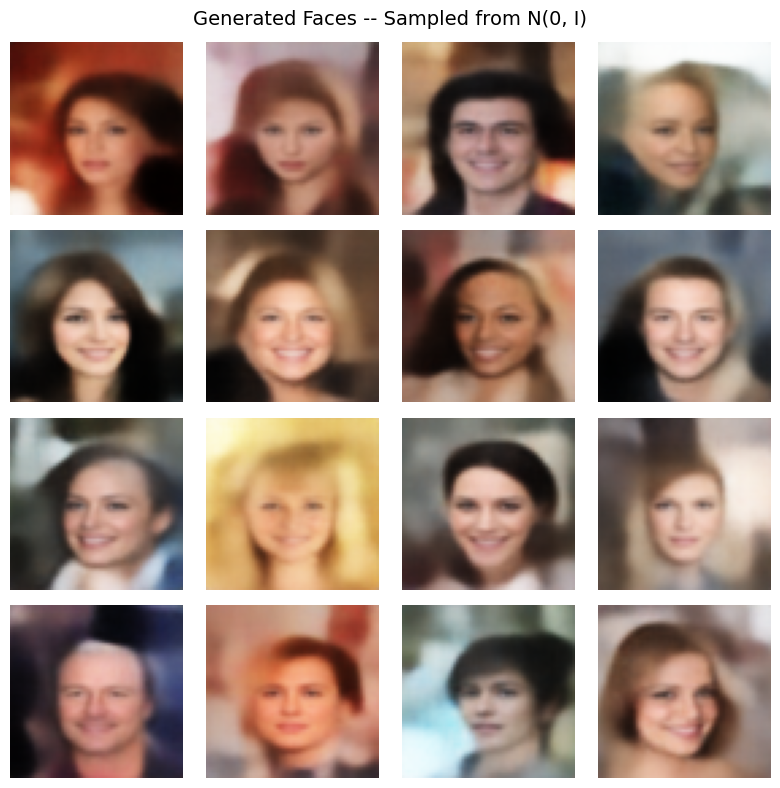

In [8]:
@torch.no_grad()
def generate_faces(model, n=16, latent_dim=128):
    model.eval()
    z = torch.randn(n, latent_dim).to(device)
    samples = model.decode(z)

    fig, axes = plt.subplots(4, 4, figsize=(8, 8))
    for i, ax in enumerate(axes.flat):
        ax.imshow(samples[i].permute(1, 2, 0).cpu())
        ax.axis('off')
    plt.suptitle("Generated Faces -- Sampled from N(0, I)", fontsize=14)
    plt.tight_layout()
    plt.show()

generate_faces(model, n=16)

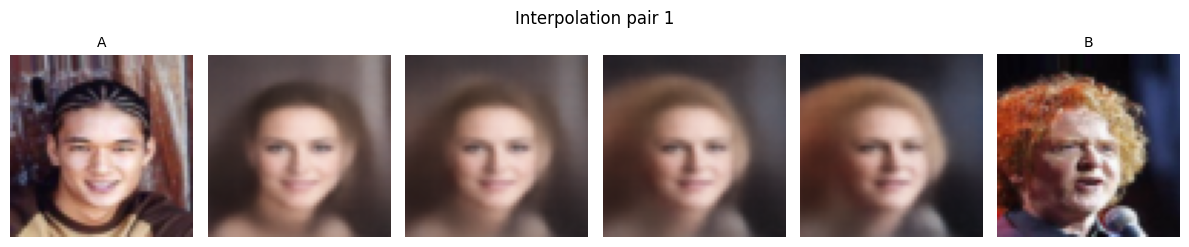

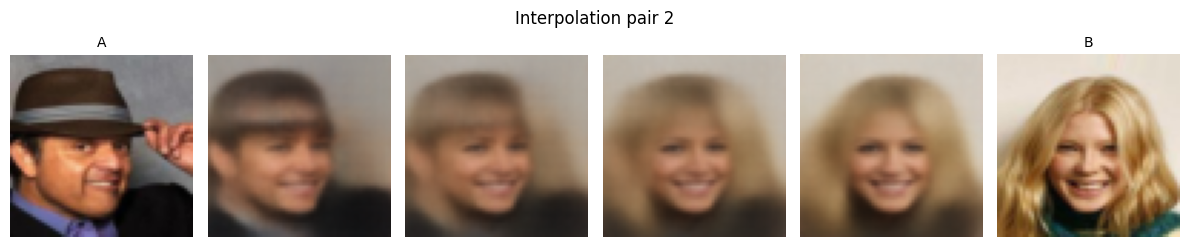

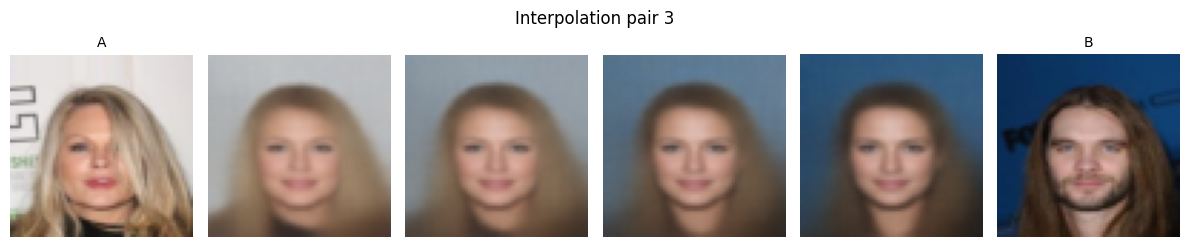

In [9]:
@torch.no_grad()
def latent_quality_check(model, loader, n_pairs=5):
    """Quick check: encode two faces, interpolate, see if transition is smooth."""
    model.eval()
    x, _ = next(iter(loader))
    x = x.to(device)

    for pair in range(n_pairs):
        img1 = x[pair*2:pair*2+1]
        img2 = x[pair*2+1:pair*2+2]

        mu1, _ = model.encode(img1)
        mu2, _ = model.encode(img2)

        fig, axes = plt.subplots(1, 6, figsize=(12, 2.5))
        axes[0].imshow(img1[0].permute(1,2,0).cpu())
        axes[0].set_title("A", fontsize=10)
        axes[0].axis('off')

        for i, alpha in enumerate([0.2, 0.4, 0.6, 0.8]):
            z_interp = (1 - alpha) * mu1 + alpha * mu2
            recon = model.decode(z_interp)
            axes[i+1].imshow(recon[0].permute(1,2,0).cpu())
            axes[i+1].axis('off')

        axes[5].imshow(img2[0].permute(1,2,0).cpu())
        axes[5].set_title("B", fontsize=10)
        axes[5].axis('off')

        plt.suptitle(f"Interpolation pair {pair+1}", fontsize=12)
        plt.tight_layout()
        plt.show()

latent_quality_check(model, val_loader, n_pairs=3)